In [418]:
import sqlite3
import pandas as pd
from tabula import read_pdf
from bs4 import BeautifulSoup
import requests
import re
from scipy.stats import zscore
import numpy as np


#### Insert data into a SQL Lite database – create a table with the following data below that you will create yourself (Hint on how to create the SQL: Python for Data Analysis 2nd edition page 191, Python for Data Analysis 3rd Edition: Page 199):
##### a. Name, Address, City, State, Zip, Phone Number
##### b. Add at least 10 rows of data and submit your code with a query generating your results.__

In [420]:
# Connect to SQLite database
con=sqlite3.connect("mydata.sqlite")

In [421]:
# Drop table if create table query abends
drop_query = """
DROP TABLE IF EXISTS test"""
con.execute(drop_query)

In [422]:
# Create query to create a table test
query = """
CREATE TABLE test
(Name VARCHAR(20), Address VARCHAR(20), City VARCHAR(20), State VARCHAR(20), Zip INTEGER(5), Phone Number INTEGER(10));"""

In [423]:
# Execute the query to create the table
con.execute(query)

In [424]:
# Commit the table  structure created
con.commit()

In [425]:
# Prep data to be inserted
data=[("John W", "2024 new street", "San Antonio", "Texas", 78240, 2109897870),
      ("Leo S", "7620 Braodway street", "San Antonio", "Texas", 78240, 2109897870),
      ("Rashmi Y", "4046 Oaks way", "San Antonio", "Texas", 78240, 2109897870),
      ("Tu Le", "63 Sagebrooke Run", "San Antonio", "Texas", 78240, 2109897870),
      ("Catherine S", "23 Fredericksburg Rd", "San Antonio", "Texas", 78240, 2109897870),
      ("Joshua Silverman", "2024 new street", "Philadelphia", "Pennsylvania", 78240, 2109897870),
      ("Garry Wylie", "46 Parksdale", "Atlanta", "Georgia", 78240, 2109897870),
      ("Tracy G", "1998 Redland Raod", "San Antonio", "Texas", 78240, 2109897870),
      ("Yud Evans", "21 State Highway 51", "Hondo", "Texas", 78240, 2109897870),
      ("Mary Garcia", "46 Steubing Park", "San Antonio", "Texas", 78240, 2109897870)]

In [426]:
# Define insert query to insert data into the table
# Use ? as a placeholder for values
# Use executemany to insert multiple rows at once
stmt = "INSERT INTO test VALUES(?,?,?,?,?,?)"
con.executemany(stmt,data)

In [427]:
# Commit the data inserted
con.commit()

In [428]:
# Read the data from the table
# Use SELECT statement to fetch all records
cursor = con.execute("SELECT * FROM test")
rows = cursor.fetchall()
rows

[('John W', '2024 new street', 'San Antonio', 'Texas', 78240, 2109897870),
 ('Leo S', '7620 Braodway street', 'San Antonio', 'Texas', 78240, 2109897870),
 ('Rashmi Y', '4046 Oaks way', 'San Antonio', 'Texas', 78240, 2109897870),
 ('Tu Le', '63 Sagebrooke Run', 'San Antonio', 'Texas', 78240, 2109897870),
 ('Catherine S',
  '23 Fredericksburg Rd',
  'San Antonio',
  'Texas',
  78240,
  2109897870),
 ('Joshua Silverman',
  '2024 new street',
  'Philadelphia',
  'Pennsylvania',
  78240,
  2109897870),
 ('Garry Wylie', '46 Parksdale', 'Atlanta', 'Georgia', 78240, 2109897870),
 ('Tracy G', '1998 Redland Raod', 'San Antonio', 'Texas', 78240, 2109897870),
 ('Yud Evans', '21 State Highway 51', 'Hondo', 'Texas', 78240, 2109897870),
 ('Mary Garcia',
  '46 Steubing Park',
  'San Antonio',
  'Texas',
  78240,
  2109897870)]

ACTIVITY 5.01: READING TABULAR DATA FROM A WEBPAGE AND CREATING DATAFRAMES      
In this activity your have been given a wikipedia page where you have the gdp of all countries listed. You have to crrate three DataFrames frin the three sources mentioned on the pahe ( https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal))

In [430]:
# Read the page using BS4

fd= open("List of countries by GDP (nominal) - Wikipedia.htm",'r',encoding='utf-8')

# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(fd)


In [431]:
# Find the table structure you will need to deal with ( How many tables are there?)

# Find all tables in the HTML
tables = soup.find_all('table')

# Print the number of tables found
print(f"Number of tables found: {len(tables)}")

Number of tables found: 9


In [432]:
# Find th right table using BS4
tables = soup.find('table', {'class': '"wikitable"|}'})


In [433]:
# Separate the source name and their corresponding data

# Source name 
src = tables.tbody.find_all('tr',recursive=False)[0]
sources = [td for td in src.findAll('td')]

# Corresponding data
#data = [row.find_all('td') for row in sources] # I m getting 212 as answer same as sources using this query by solution have 3

data = tables.tbody.findAll('tr', recursive=False)[1].findAll('td', recursive=False)
data_tables = []
for td in data:
    data_tables.append(td.findAll('table'))
    
print(len(data_tables))
print(len(sources))

3
3


In [434]:
# Get the source names from the list of sources you have created 
# source_names = []
# for source in sources.findAll('td'):
#     source_names.append(source.get_text(strip=True))
# print(source_names)

source_names = [source.findAll('a')[0].getText() for source in sources]
print(source_names)

['International Monetary Fund', 'World Bank', 'United Nations']


In [435]:
# Separate the header and  data from the data that you separated before for the first source only and then create a dataframe using that
# Get the header
# header1 = [th.getText(strip=True) for th in tables.find_all('th')]

header1 = [th.getText().strip() for th in data_tables[0][0].findAll('thead')[0].findAll('th')]
# print(header1)

#Get data table rows
# row1 = tables.findAll('tbody')[0].find_all('tr')
rows1 = data_tables[0][0].findAll('tbody')[0].findAll('tr')
# Stripping td Tags
td_rows1 = [[td.get_text().strip() for td in tr.findAll('td')] for tr in rows1]
# print(rows1)

#Creating a dataframe

df = pd.DataFrame(td_rows1, columns = header1)
df.head(5)

,Rank,Country,GDP(US$MM)
0,,World[19],"79,865,481"
1,1,United States,"19,390,600"
2,2,China[n 1],"12,014,610"
3,3,Japan,"4,872,135"
4,4,Germany,"3,684,816"


In [436]:
# Process the third source
header2 = [th.getText().strip() for th in data_tables[0][0].findAll('thead')[0].findAll('th')]

# Get data table rows
rows2 = data_tables[0][0].findAll('tbody')[0].findAll('tr')

# Stripping td Tags
td_rows2 = [[td.get_text().strip() for td in tr.findAll('td')] for tr in rows2]

# Creating a dataframe
df1 = pd.DataFrame(td_rows3, columns=header3)
df1.head(5)

,Rank,Country,GDP(US$MM)
0,,World[19],"79,865,481"
1,1,United States,"19,390,600"
2,2,China[n 1],"12,014,610"
3,3,Japan,"4,872,135"
4,4,Germany,"3,684,816"


In [437]:
# Process the third source
header3 = [th.getText().strip() for th in data_tables[0][0].findAll('thead')[0].findAll('th')]

# Get data table rows
rows3 = data_tables[0][0].findAll('tbody')[0].findAll('tr')

# Stripping td Tags
td_rows3 = [[td.get_text().strip() for td in tr.findAll('td')] for tr in rows3]

# Creating a dataframe
df2 = pd.DataFrame(td_rows3, columns=header3)
df2.head(5)

,Rank,Country,GDP(US$MM)
0,,World[19],"79,865,481"
1,1,United States,"19,390,600"
2,2,China[n 1],"12,014,610"
3,3,Japan,"4,872,135"
4,4,Germany,"3,684,816"


#### Activity 6.01 : Handling outliers & missing Data

In [439]:
df_csv = pd.read_csv("visit_data.csv")
df_csv.shape

(1000, 7)

In [440]:
#  check Duplcates
df_csv_dup = df_csv.drop_duplicates()
df_csv_dup.shape

#  same rows, no duplicate rows present



(1000, 7)

In [441]:
# check NaN
print(df_csv.isna().sum())

# looking at below data, we can see that there are some NaN values in the data
# the first and last names have around 296 missing values, and 26 missing values for visit.

initial_shape = df_csv.shape
df_csv.head()
print(initial_shape)

id              0
first_name    296
last_name     296
email           0
gender        505
ip_address      0
visit          26
dtype: int64
(1000, 7)


In [442]:
# Lets drop the missing visit rows on axis = 0
df_csv.dropna(subset=['visit'], inplace=True)
print(df_csv.isna().sum())

post_NAN = df_csv.shape
df_csv.head()
print(post_NAN)

id              0
first_name    287
last_name     287
email           0
gender        493
ip_address      0
visit           0
dtype: int64
(974, 7)


In [443]:
# Get Zscores for all numerical values

#  First separate numerical columns
numerical_columns = df_csv.select_dtypes(include=['float64', 'int64']).columns
z_scores = df_csv[numerical_columns].apply(zscore)
#print(z_scores)

# Get the outliers
outliers = (z_scores.abs() > 3).sum()
outliers

id       0
visit    0
dtype: int64

In [444]:
# Report size the difference
print(tuple(a - b for a, b in zip(initial_shape, post_NAN)))

(26, 0)


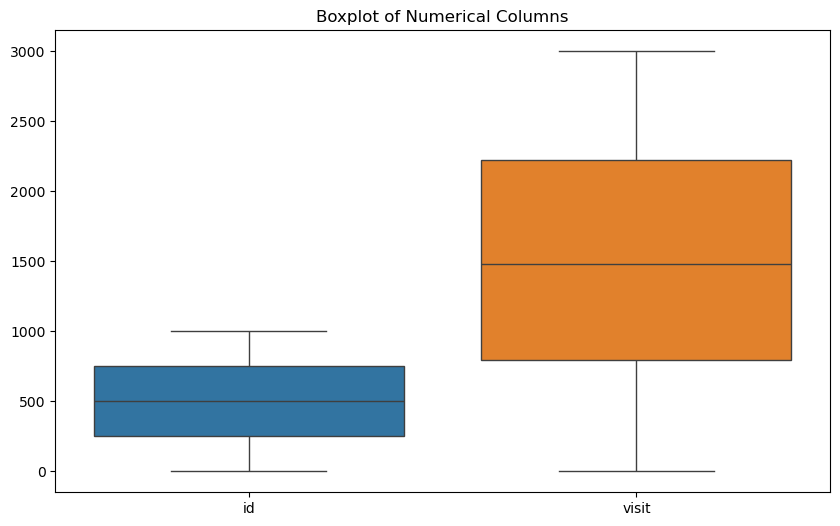

In [445]:
# Create a box plot to check the outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_csv[numerical_columns])
plt.title('Boxplot of Numerical Columns')
plt.show()


In [458]:
#  Get rid of values below 100 and above 2900
df_csv = df_csv[(df_csv['visit'] >= 100) & (df_csv['visit'] <= 2900)]
final_shape = df_csv.shape


#  Check the shape of the data
print(" Initial shape: {}".format(initial_shape[0]))
print(" Post NaN shape: {}".format(post_NAN[0]))
print(" Final shape: {}".format(final_shape[0]))


 Initial shape: 1000
 Post NaN shape: 974
 Final shape: 923
